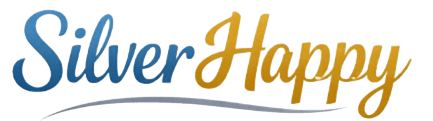

# Imports :

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Initialisation des paramètres :

In [ ]:
np.random.seed(42)

n_lignes = 1200
villes = ['Lille', 'Bordeaux', 'Toulouse', 'Marseille', 'Strabourg', 'Lyon', 'Orléans', 'Paris', 'Montreuil', 'Créteil', 'Fontainebleau', 'Creil', 'Rouen']
sexes = ['Femme', 'Homme']
types_abonnement = ['Mensuel', 'Annuel']
prestations = ['Sport', 'Aide à domicile', 'Cours divers', 'Séjour & Voyages', 'Sorties culturelles', 'Bin-être & Massages']

data = []

# Génération du dataset :

In [ ]:
for i in range(n_lignes):
    id_client = i + 1
    age = np.random.randint(60, 95)
    sexe = random.choice(sexes)
    ville = random.choice(villes)
    type_abonnement = random.choice(types_abonnement)

    anciennete = np.random.randint(1, 7)

    note_moyenne = np.random.uniform(1, 6)

    if age > 80:
        prestation_choisie = random.choices(prestations, weights=[0.03, 0.85, 0.03, 0.03, 0.03, 0.03])[0]
    elif age < 75 and sexe == 'Femme':
        prestation_choisie = random.choices(prestations, weights=[0.03, 0.03, 0.03, 0.03, 0.03, 0.85])[0]
    elif age < 70 and sexe == 'Homme':
        prestation_choisie = random.choices(prestations, weights=[0.85, 0.03, 0.03, 0.03, 0.03, 0.03])[0]
    elif age < 65:
        prestation_choisie = random.choices(prestations, weights=[0.05, 0.75, 0.05, 0.05, 0.05, 0.05])[0]
    elif type_abonnement == 'Annuel' and nb_inscriptions > 6:
        prestation_choisie = random.choices(prestations, weights=[0.04, 0.04, 0.04, 0.80, 0.04, 0.04])[0]
    else:
        prestation_choisie = random.choices(prestations, weights=[0.10, 0.10, 0.30, 0.10, 0.30, 0.10])[0]

    if type_abonnement == 'Annuel':
        nb_inscriptions = np.random.randint(4, 13) + (anciennete // 2)
    else:
        nb_inscriptions = np.random.randint(1, 5)

    nb_inscriptions = max(1, nb_inscriptions)

    data.append([
        id_client, age, sexe, ville, type_abonnement,
        anciennete, note_moyenne, nb_inscriptions, prestation_choisie
    ])

df = pd.DataFrame(data, columns=[
    'ID_Adherent', 'Age', 'Sexe', 'Ville', 'Type_Abonnement',
    'Ancienneté', 'Note_Moyenne', 'Nb_Inscriptions', 'Prestation_Cible'
])

# Export  et visualisation du dataset :

In [ ]:
df.to_csv('dataset_silver_happy.csv', index=False)

In [ ]:
df.head()

,ID_Adherent,Age,Sexe,Ville,Type_Abonnement,Ancienneté,Note_Moyenne,Nb_Inscriptions,Prestation_Cible
0,1,88,Homme,Créteil,Mensuel,3,4.898455,1,Cours divers
1,2,78,Homme,Toulouse,Mensuel,3,3.296244,1,Sorties culturelles
2,3,83,Femme,Montreuil,Mensuel,3,1.102922,2,Aide à domicile
3,4,83,Femme,Bordeaux,Mensuel,4,5.692764,2,Aide à domicile
4,5,80,Femme,Bordeaux,Mensuel,1,2.521211,2,Cours divers


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Adherent       1200 non-null   int64  
 1   Age               1200 non-null   int64  
 2   Sexe              1200 non-null   object 
 3   Ville             1200 non-null   object 
 4   Type_Abonnement   1200 non-null   object 
 5   Ancienneté        1200 non-null   int64  
 6   Note_Moyenne      1200 non-null   float64
 7   Nb_Inscriptions   1200 non-null   int64  
 8   Prestation_Cible  1200 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 84.5+ KB


# Répartition du sexe chez les adhérents :

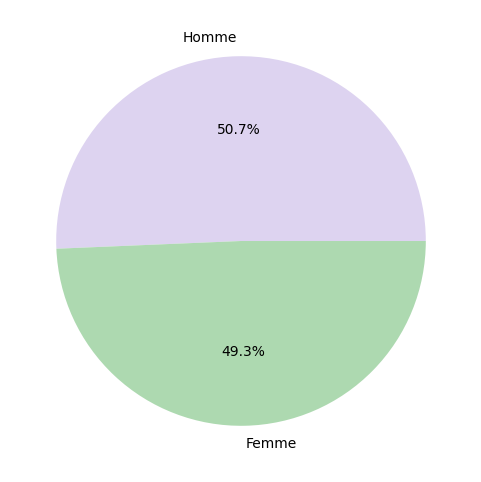

In [ ]:
plt.figure(figsize=(6, 6))
counts = df['Sexe'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#DDD3F0', '#ADD9B0'])
plt.show()

# Répartition de l'âge chez les adhérents :

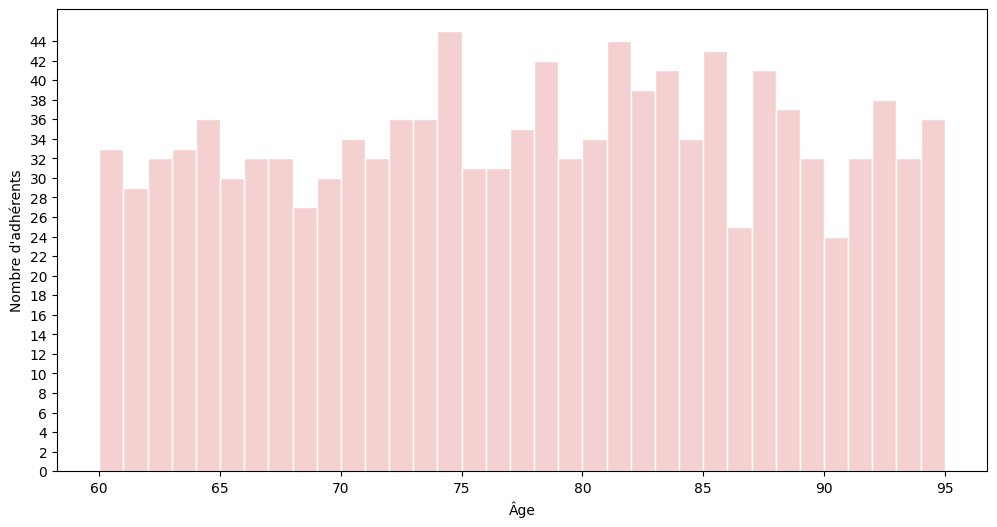

In [ ]:
plt.figure(figsize=(12, 6))
bins = range(df['Age'].min(), df['Age'].max() + 2)
df['Age'].hist(bins=bins, color='#F5D0D0', edgecolor='white', grid=False)
plt.xlabel('Âge')
plt.ylabel('Nombre d\'adhérents')
plt.yticks(range(0, 45, 2))
plt.show()

# Répartition par ville des adhérents :

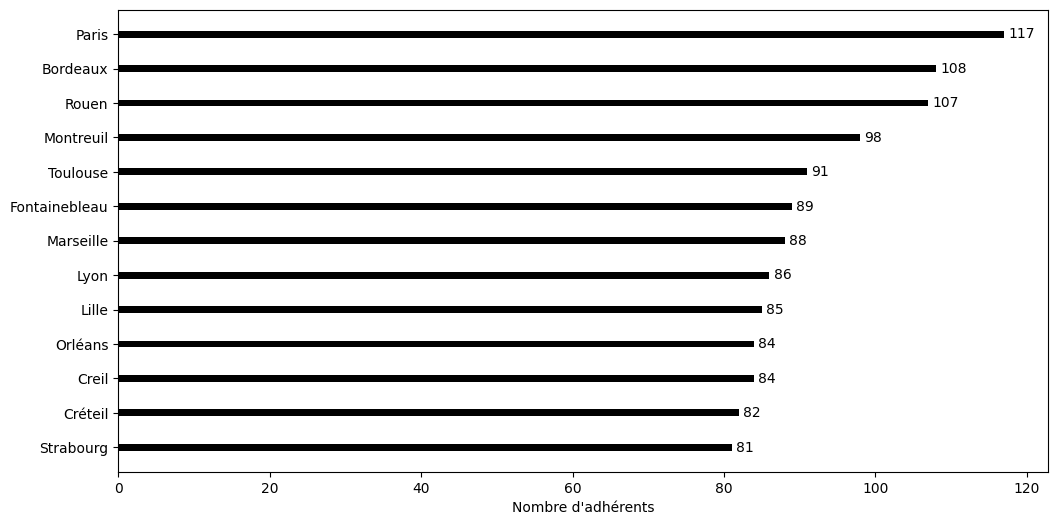

In [ ]:
plt.figure(figsize=(12, 6))
counts = df['Ville'].value_counts().sort_values(ascending=True)

bars = plt.barh(counts.index, counts.values, color='black', height=0.2)

plt.bar_label(bars, padding=3)

plt.xlabel('Nombre d\'adhérents')
plt.show()

# Impact de l'âge sur le type d'abonnement :

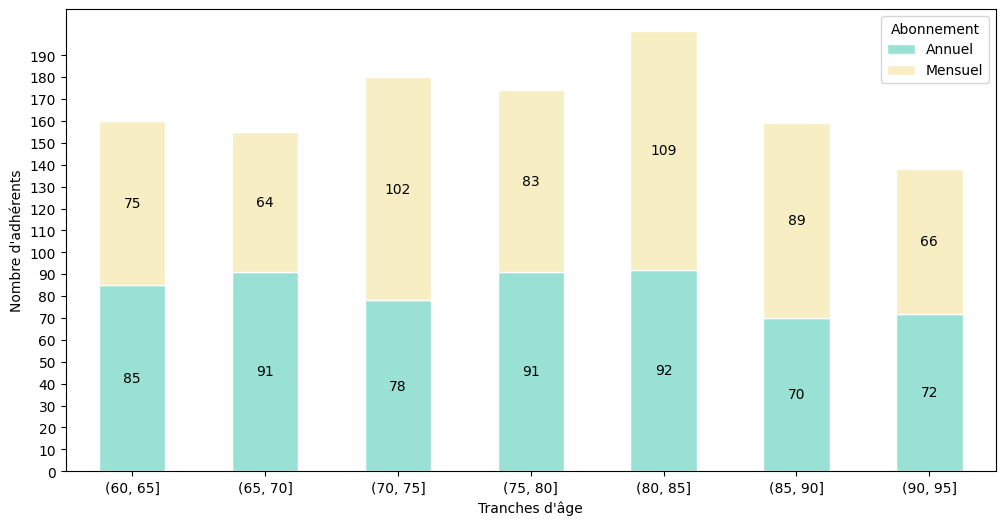

In [ ]:
df['Tranche_Age'] = pd.cut(df['Age'], bins=range(60, 96, 5))

df_cross = pd.crosstab(df['Tranche_Age'], df['Type_Abonnement'])

ax = df_cross.plot(kind='bar', color=['#99E0D5', '#F7EEC3'], figsize=(12, 6), stacked=True, edgecolor='white')

for container in ax.containers:
    ax.bar_label(container, label_type='center', color='black')

plt.xlabel('Tranches d\'âge')
plt.xticks(rotation=0)
plt.ylabel('Nombre d\'adhérents')
plt.yticks(range(0, 200, 10))
plt.legend(title='Abonnement')
plt.show()

# Succès (nombre d'inscription) des différentes prestations :

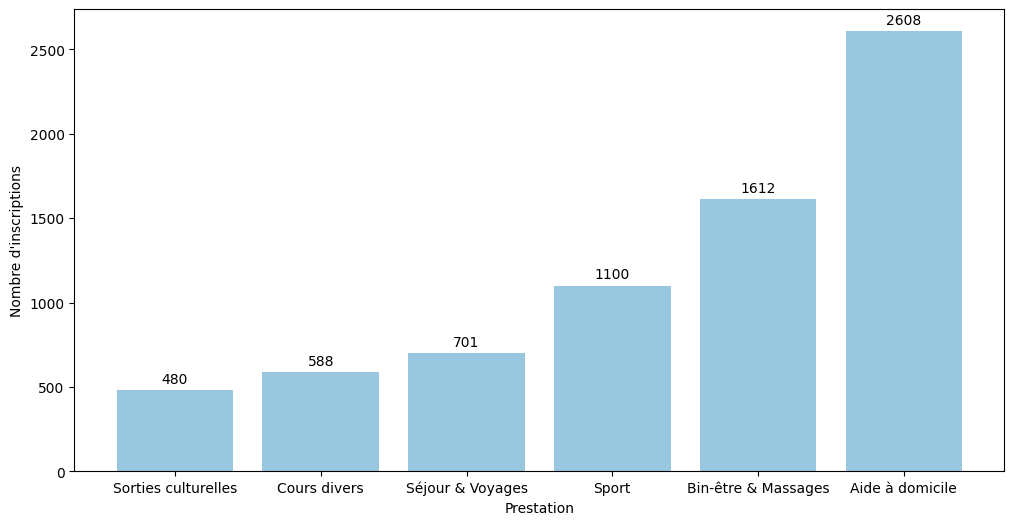

In [ ]:
plt.figure(figsize=(12, 6))

succes = df.groupby('Prestation_Cible')['Nb_Inscriptions'].sum().sort_values()

bars = plt.bar(succes.index, succes.values, color='#99C7E0')

plt.bar_label(bars, padding=3)

plt.xlabel("Prestation")
plt.ylabel("Nombre d'inscriptions")

plt.show()

# Nombre moyen de réinscription par prestation

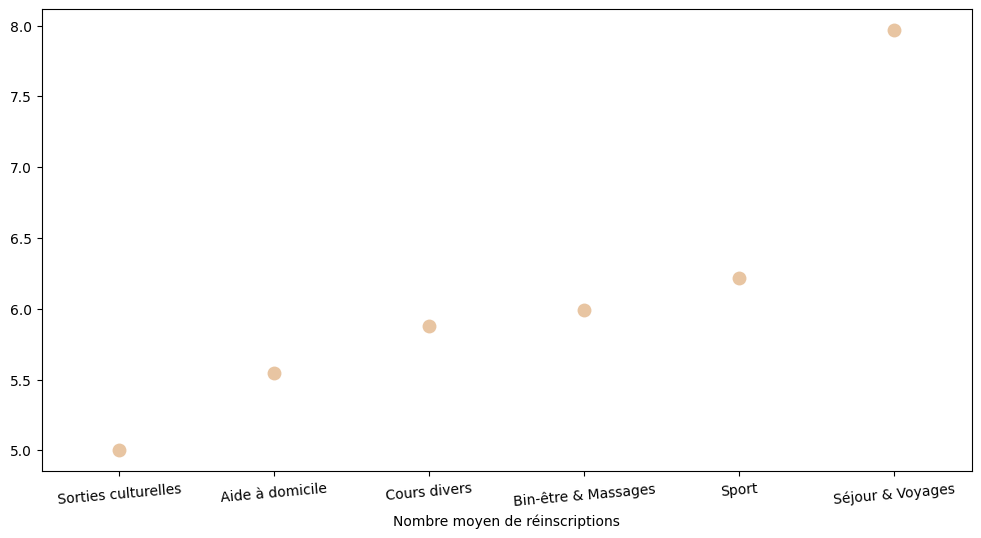

In [ ]:
plt.figure(figsize=(12, 6))

reinscription = df.groupby('Prestation_Cible')['Nb_Inscriptions'].mean().sort_values()

sns.stripplot(x=reinscription.index, y=reinscription.values, size=10, color='#E8C5A2')

plt.xlabel("Nombre moyen de réinscriptions")
plt.xticks(rotation=5)
plt.show()

# Nombre d'avis par note et par prestation



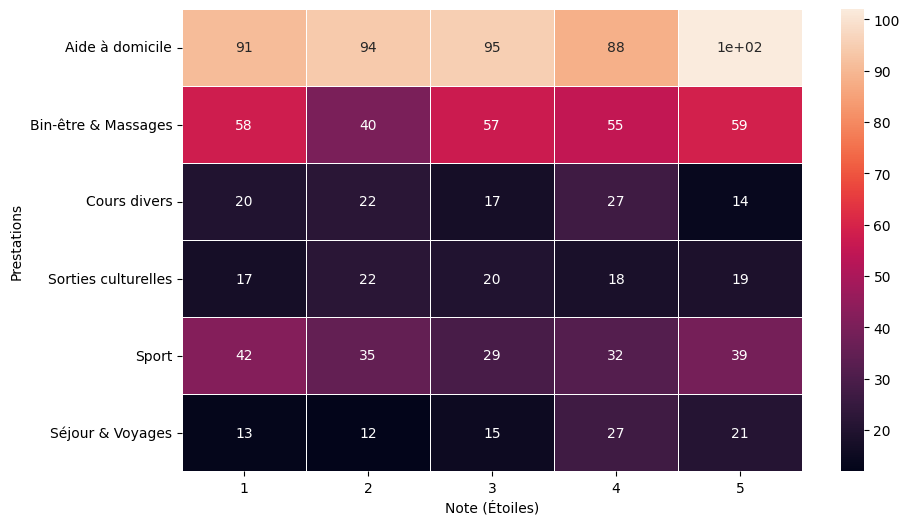

In [ ]:
df['Note_Moyenne'] = df['Note_Moyenne'].astype(int)
df_notes = pd.crosstab(df['Prestation_Cible'], df['Note_Moyenne'])

plt.figure(figsize=(10, 6))
sns.heatmap(df_notes, annot=True, linewidths=.5)

plt.xlabel('Note (Étoiles)')
plt.ylabel('Prestations')
plt.show()

# Nettoyage dataframe

In [ ]:
df_clean = df.dropna(subset=['Prestation_Cible']).copy()

df_clean['Sexe_Clean'] = df_clean['Sexe'].map({'Homme': 0, 'Femme': 1})
df_clean['Abo_Clean'] = df_clean['Type_Abonnement'].map({'Mensuel': 0, 'Annuel': 1})
villes_mapping = {val: i for i, val in enumerate(df_clean['Ville'].unique())}
df_clean['Ville_Clean'] = df_clean['Ville'].map(villes_mapping)

y = df_clean['Prestation_Cible']
X = df_clean[['Age', 'Ancienneté', 'Note_Moyenne', 'Nb_Inscriptions', 'Sexe_Clean', 'Ville_Clean', 'Abo_Clean']]

# Préparation des données

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(960, 7)

In [ ]:
X_test.shape

(240, 7)

# Traitement des données

In [ ]:
scaler = StandardScaler().set_output(transform="pandas")

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrainement modèle

In [ ]:
model = RandomForestClassifier(random_state=42)

start_time = time.time()
model.fit(X_train_scaled, y_train)
end_time = time.time()

execution_time = end_time - start_time

print(f"Temps d'entraînement : {execution_time:.3f} secondes")

Temps d'entraînement : 0.388 secondes


# Prédiction modèle

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")

Accuracy : 0.754


In [ ]:
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

    Aide à domicile       0.87      0.95      0.91       110
Bin-être & Massages       0.83      0.83      0.83        46
       Cours divers       0.33      0.19      0.24        16
Sorties culturelles       0.36      0.24      0.29        17
              Sport       0.72      0.66      0.69        35
   Séjour & Voyages       0.39      0.56      0.46        16

           accuracy                           0.75       240
          macro avg       0.58      0.57      0.57       240
       weighted avg       0.74      0.75      0.74       240



# Exemple de prédiction

In [ ]:
data_client = [[75, 2, 4, 1, 1, 0, 1]]
nouveau_client = pd.DataFrame(data_client, columns=X.columns)
nouveau_client_scaled = scaler.transform(nouveau_client)
prediction = model.predict(nouveau_client_scaled)

print(f"La prestation recommandée est : {prediction[0]}")

La prestation recommandée est : Cours divers
